# Optativa III: Ciencia de Datos
## Actividad práctica — Estadística descriptiva e inferencial con `scipy.stats`

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 2**

---

### Propósito de la actividad

En esta actividad calcularás **medidas de tendencia central y dispersión**, generarás y visualizarás las distribuciones **normal, binomial y Poisson**, y comprobarás de forma empírica el **teorema del límite central**.

No se trata solo de ejecutar el código: en cada bloque encontrarás **preguntas** y **retos de modificación**. Debes cambiar valores, volver a ejecutar y explicar qué observas. El aprendizaje ocurre cuando experimentas.

### Cómo trabajar en Google Colab

1. Abre este archivo en [Google Colab](https://colab.research.google.com) (Archivo → Subir cuaderno).
2. Ejecuta cada celda de código con **Shift + Enter**, en orden.
3. Responde las preguntas en las celdas de texto marcadas con ✍️ (haz doble clic para editar).
4. Al terminar, ve a **Archivo → Guardar una copia en Drive**, y entrega el enlace en Classroom.

> **Importante:** ejecuta las celdas en orden. Si una falla, revisa que hayas corrido las anteriores.


---
## Paso 0 — Preparación del entorno

Importamos las librerías. En Colab ya vienen instaladas, así que solo hay que importarlas.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Semilla para que los resultados aleatorios sean reproducibles
# (todos obtendran los mismos numeros al usar la misma semilla)
np.random.seed(42)

print("Librerias cargadas correctamente.")
print("Version de numpy:", np.__version__)

ModuleNotFoundError: No module named 'scipy'

> ✍️ **Pregunta 0.1** — ¿Para qué sirve `np.random.seed(42)`? ¿Qué pasaría si cada estudiante usara una semilla distinta al comparar resultados?

*(Escribe tu respuesta aquí, haciendo doble clic)*


✍️ **Respuesta 0.1**

`np.random.seed(42)` se utiliza para inicializar el generador de números pseudoaleatorios. Al fijar la "semilla" con un número específico (como 42), se asegura que cada vez que se ejecute el código, se producirá la misma secuencia de números "aleatorios". Esto es crucial para la **reproducibilidad**, permitiendo que diferentes personas (o la misma persona en diferentes momentos) obtengan exactamente los mismos resultados en experimentos o simulaciones que involucren aleatoriedad.

Si cada estudiante usara una semilla distinta al comparar resultados, sus secuencias de números aleatorios serían diferentes. Esto significaría que, aunque el código fuera idéntico, los resultados numéricos de sus simulaciones o análisis podrían variar. Esto dificultaría enormemente la comparación y verificación de sus trabajos, ya que las diferencias observadas podrían deberse a la variación aleatoria y no a errores o enfoques distintos en el código.

---
## Paso 1 — Medidas de tendencia central y dispersión

Vamos a simular las **calificaciones finales de un grupo de 40 estudiantes**. Primero las creamos y luego las describimos estadísticamente.


In [ ]:
# Calificaciones simuladas de 40 estudiantes (escala 0-100)
calificaciones = np.array([
    78, 85, 90, 72, 88, 95, 60, 74, 82, 91,
    68, 77, 84, 79, 93, 70, 86, 81, 75, 89,
    65, 80, 87, 76, 92, 73, 83, 69, 94, 71,
    88, 78, 85, 90, 67, 82, 79, 86, 74, 100
])

print("Numero de estudiantes:", len(calificaciones))
print("Calificaciones:", calificaciones)

Numero de estudiantes: 40
Calificaciones: [ 78  85  90  72  88  95  60  74  82  91  68  77  84  79  93  70  86  81
  75  89  65  80  87  76  92  73  83  69  94  71  88  78  85  90  67  82
  79  86  74 100]


In [ ]:
# --- Medidas de TENDENCIA CENTRAL ---
media    = np.mean(calificaciones)
mediana  = np.median(calificaciones)
moda     = stats.mode(calificaciones, keepdims=True)

print("MEDIDAS DE TENDENCIA CENTRAL")
print(f"  Media    (promedio):        {media:.2f}")
print(f"  Mediana  (valor central):   {mediana:.2f}")
print(f"  Moda     (mas frecuente):   {moda.mode[0]}  (aparece {moda.count[0]} veces)")

print()

# --- Medidas de DISPERSION ---
rango       = np.max(calificaciones) - np.min(calificaciones)
varianza    = np.var(calificaciones, ddof=1)   # ddof=1 -> varianza muestral
desv_est    = np.std(calificaciones, ddof=1)   # desviacion estandar muestral
rango_iq    = stats.iqr(calificaciones)        # rango intercuartilico

print("MEDIDAS DE DISPERSION")
print(f"  Rango:                      {rango}")
print(f"  Varianza (muestral):        {varianza:.2f}")
print(f"  Desviacion estandar:        {desv_est:.2f}")
print(f"  Rango intercuartilico (IQR):{rango_iq:.2f}")

MEDIDAS DE TENDENCIA CENTRAL
  Media    (promedio):        80.90
  Mediana  (valor central):   81.50
  Moda     (mas frecuente):   74  (aparece 2 veces)

MEDIDAS DE DISPERSION
  Rango:                      40
  Varianza (muestral):        85.17
  Desviacion estandar:        9.23
  Rango intercuartilico (IQR):14.00


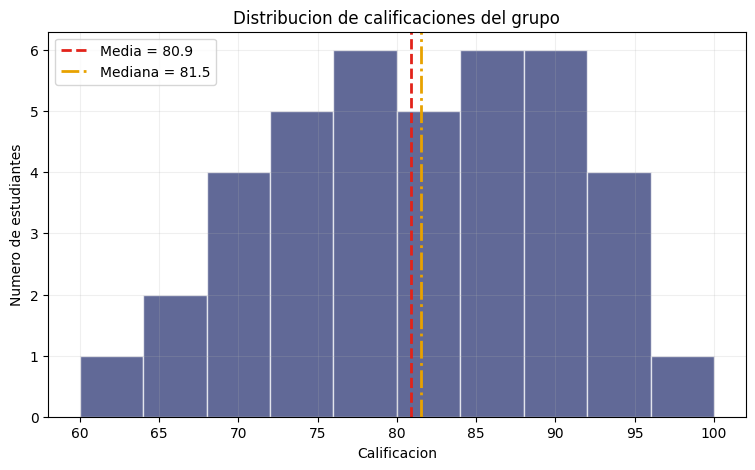

In [ ]:
# Visualizamos las calificaciones con un histograma y las medidas centrales
plt.figure(figsize=(9,5))
plt.hist(calificaciones, bins=10, color="#1e2a6b", alpha=0.7, edgecolor="white")
plt.axvline(media,   color="#e2231a", linewidth=2, linestyle="--", label=f"Media = {media:.1f}")
plt.axvline(mediana, color="#e8a200", linewidth=2, linestyle="-.", label=f"Mediana = {mediana:.1f}")
plt.title("Distribucion de calificaciones del grupo")
plt.xlabel("Calificacion")
plt.ylabel("Numero de estudiantes")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

> ✍️ **Pregunta 1.1** — Observa el histograma. ¿La media y la mediana están cerca o lejos entre sí? ¿Qué te dice eso sobre la simetría de las calificaciones?

> ✍️ **Pregunta 1.2** — ¿Por qué usamos `ddof=1` para la varianza y la desviación estándar? Investiga la diferencia entre varianza **poblacional** y **muestral**.


✍️ **Respuesta 1.1**

Al observar el histograma y los valores de la media (80.90) y la mediana (81.50), notamos que están muy cerca entre sí. Esto indica que la distribución de las calificaciones es **casi simétrica**. En una distribución perfectamente simétrica, la media y la mediana serían idénticas.

✍️ **Respuesta 1.2**

Utilizamos `ddof=1` (Delta Degrees of Freedom = 1) para calcular la varianza y la desviación estándar **muestrales**.

*   La **varianza poblacional** se calcula dividiendo la suma de los cuadrados de las diferencias entre cada dato y la media, entre el número total de datos (`N`). Se usa cuando tenemos todos los datos de la población.
*   La **varianza muestral** se calcula dividiendo la suma de los cuadrados de las diferencias entre cada dato y la media, entre el número total de datos menos uno (`n-1`). Se usa cuando tenemos una muestra de la población y queremos estimar la varianza de la población a partir de esa muestra. El `-1` en el denominador (la corrección de Bessel) se aplica para obtener un estimador insesgado de la varianza poblacional, es decir, para corregir el hecho de que la variabilidad en una muestra tiende a subestimar la variabilidad real de la población de la que proviene.

En este caso, las 40 calificaciones son una muestra, no la población entera de estudiantes, por lo que usamos `ddof=1` para obtener una estimación más precisa de la varianza real si consideráramos este grupo como una muestra de un grupo más grande de estudiantes.

### 🔧 Reto de modificación 1

En la siguiente celda, **agrega un estudiante con una calificación atípica muy baja** (por ejemplo, 10) y observa cómo cambian la media y la mediana.


In [ ]:
# RETO: agrega el valor 10 al final del arreglo y vuelve a calcular
# Pista: usa np.append(calificaciones, 10)

calificaciones_con_atipico = np.append(calificaciones, 10)   # <-- modifica este valor y experimenta

print("Sin valor atipico -> Media:", round(np.mean(calificaciones),2),
      " Mediana:", np.median(calificaciones))
print("Con valor atipico -> Media:", round(np.mean(calificaciones_con_atipico),2),
      " Mediana:", np.median(calificaciones_con_atipico))

Sin valor atipico -> Media: 80.9  Mediana: 81.5
Con valor atipico -> Media: 79.17  Mediana: 81.0


> ✍️ **Pregunta 1.3** — ¿Cuál medida cambió más al agregar el valor atípico: la media o la mediana? Con base en esto, ¿cuál medida es más **robusta** ante valores extremos y por qué es importante saberlo al analizar datos reales (por ejemplo, salarios o precios)?


✍️ **Respuesta 1.3**

Al agregar el valor atípico (10), la **media** cambió de 80.9 a 79.17 (una disminución de 1.73 puntos), mientras que la **mediana** cambió de 81.5 a 81.0 (una disminución de solo 0.5 puntos). Claramente, la media cambió más.

Esto significa que la **mediana es una medida más robusta** ante valores extremos (outliers). La media se ve fuertemente influenciada por los valores atípicos porque utiliza todos los valores en su cálculo, dándoles el mismo peso. La mediana, al ser el valor central, es menos sensible a los valores extremos, ya que su cálculo solo depende del orden de los datos y no de la magnitud exacta de los valores más alejados.

Es importante saber esto al analizar datos reales (como salarios o precios) porque en muchas situaciones, los valores extremos pueden distorsionar la percepción de la "normalidad". Por ejemplo, si calculamos el salario promedio de un equipo incluyendo al CEO, la media podría ser muy alta y no representar el salario típico de la mayoría de los empleados. En esos casos, la mediana ofrecería una imagen más fiel de la tendencia central.

---
## Paso 2 — Distribución Normal (Gaussiana)

La distribución normal es la famosa "campana". Se define por su **media (μ)** y su **desviación estándar (σ)**. Muchos fenómenos naturales la siguen.


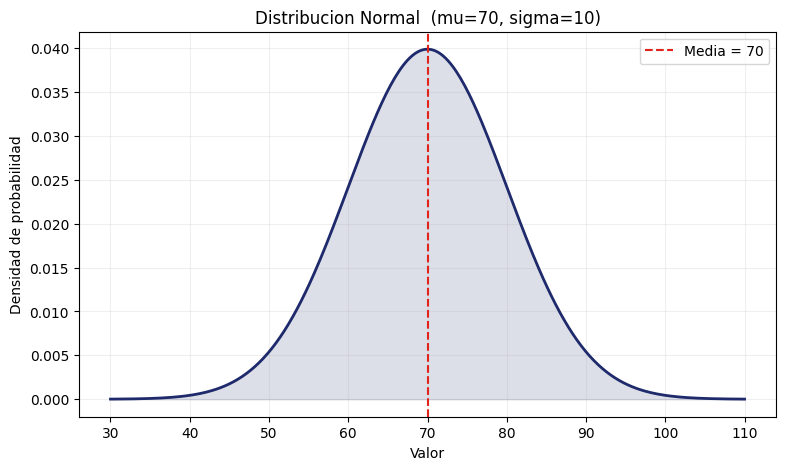

In [ ]:
# Parametros de la distribucion normal
mu    = 70    # media
sigma = 10    # desviacion estandar

# Generamos el eje x y la funcion de densidad
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
densidad = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(9,5))
plt.plot(x, densidad, color="#1e2a6b", linewidth=2)
plt.fill_between(x, densidad, alpha=0.15, color="#1e2a6b")
plt.axvline(mu, color="#e2231a", linestyle="--", label=f"Media = {mu}")
plt.title(f"Distribucion Normal  (mu={mu}, sigma={sigma})")
plt.xlabel("Valor")
plt.ylabel("Densidad de probabilidad")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# Calculamos probabilidades con la distribucion normal
# Ejemplo: si las calificaciones son Normal(70, 10)...

p_menor_60 = stats.norm.cdf(60, mu, sigma)          # P(X < 60): probabilidad de reprobar
p_mayor_90 = 1 - stats.norm.cdf(90, mu, sigma)      # P(X > 90): probabilidad de excelencia
p_entre    = stats.norm.cdf(80, mu, sigma) - stats.norm.cdf(60, mu, sigma)  # P(60 < X < 80)

print(f"P(calificacion < 60) = {p_menor_60:.3f}  ->  {p_menor_60*100:.1f}% reprobaria")
print(f"P(calificacion > 90) = {p_mayor_90:.3f}  ->  {p_mayor_90*100:.1f}% excelencia")
print(f"P(60 < calif < 80)   = {p_entre:.3f}  ->  {p_entre*100:.1f}% en rango medio")

> ✍️ **Pregunta 2.1** — Ejecuta la celda con `mu=70` y `sigma=10`. Ahora cambia `sigma` a **20** y vuelve a ejecutar ambas celdas. ¿La campana se vuelve más ancha o más angosta? ¿Qué significa eso en términos de la variabilidad de las calificaciones?

> ✍️ **Pregunta 2.2** — Con `mu=70, sigma=10`, ¿qué porcentaje de estudiantes reprobaría (calificación menor a 60)? ¿Y si el profesor mejora su enseñanza y ahora `mu=78`? Modifica el valor, ejecuta y anota ambos resultados.


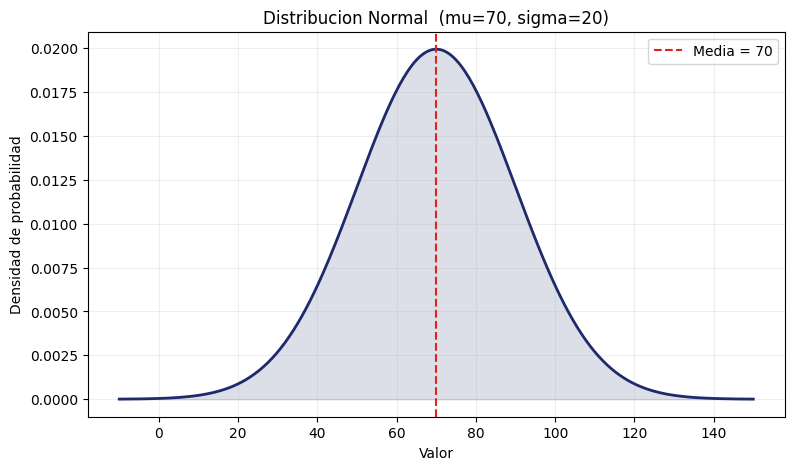

In [ ]:
# Para Pregunta 2.1: Modificar sigma a 20
mu = 70
sigma = 20 # Cambiado de 10 a 20

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
densidad = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(9,5))
plt.plot(x, densidad, color="#1e2a6b", linewidth=2)
plt.fill_between(x, densidad, alpha=0.15, color="#1e2a6b")
plt.axvline(mu, color="#e2231a", linestyle="--", label=f"Media = {mu}")
plt.title(f"Distribucion Normal  (mu={mu}, sigma={sigma})")
plt.xlabel("Valor")
plt.ylabel("Densidad de probabilidad")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# Para Pregunta 2.2: Calculo de probabilidades con mu=78
mu_original = 70
sigma = 10

p_menor_60_mu70 = stats.norm.cdf(60, mu_original, sigma) # P(X < 60) con mu=70

mu_nueva = 78 # Nueva media
p_menor_60_mu78 = stats.norm.cdf(60, mu_nueva, sigma) # P(X < 60) con mu=78

print(f"Con mu=70, sigma=10: P(calificacion < 60) = {p_menor_60_mu70:.3f}  ->  {p_menor_60_mu70*100:.1f}% reprobaria")
print(f"Con mu=78, sigma=10: P(calificacion < 60) = {p_menor_60_mu78:.3f}  ->  {p_menor_60_mu78*100:.1f}% reprobaria")

Con mu=70, sigma=10: P(calificacion < 60) = 0.159  ->  15.9% reprobaria
Con mu=78, sigma=10: P(calificacion < 60) = 0.036  ->  3.6% reprobaria


✍️ **Respuesta 2.1**

Al cambiar `sigma` de 10 a 20, la campana se vuelve **más ancha y menos alta**. Esto significa que la variabilidad de las calificaciones es mayor; los datos están más dispersos alrededor de la media. En el contexto de las calificaciones, una `sigma` más grande implica que hay una mayor diversidad en el rendimiento de los estudiantes, con más estudiantes obteniendo calificaciones muy bajas y muy altas, y menos concentrados alrededor del promedio.

✍️ **Respuesta 2.2**

*   Con `mu=70, sigma=10`, la probabilidad de que un estudiante repruebe (calificación menor a 60) es de **0.159 o 15.9%**.
*   Si el profesor mejora su enseñanza y `mu=78` (manteniendo `sigma=10`), la probabilidad de que un estudiante repruebe (calificación menor a 60) se reduce drásticamente a **0.036 o 3.6%**.

### 🔧 Reto de modificación 2

La **regla empírica** (68-95-99.7) dice que en una normal, aproximadamente el 68% de los datos cae dentro de 1σ de la media, el 95% dentro de 2σ y el 99.7% dentro de 3σ. Compruébalo con código.


In [ ]:
# RETO: verifica la regla empirica 68-95-99.7
mu, sigma = 70, 10

for k in [1, 2, 3]:
    limite_inf = mu - k*sigma
    limite_sup = mu + k*sigma
    prob = stats.norm.cdf(limite_sup, mu, sigma) - stats.norm.cdf(limite_inf, mu, sigma)
    print(f"Dentro de {k} sigma  ({limite_inf} a {limite_sup}):  {prob*100:.1f}% de los datos")

Dentro de 1 sigma  (60 a 80):  68.3% de los datos
Dentro de 2 sigma  (50 a 90):  95.4% de los datos
Dentro de 3 sigma  (40 a 100):  99.7% de los datos


> ✍️ **Pregunta 2.3** — ¿Los porcentajes que obtuviste coinciden con la regla 68-95-99.7? Explica con tus palabras por qué esta regla es útil para detectar valores anómalos en un conjunto de datos.


✍️ **Respuesta 2.3**

Sí, los porcentajes obtenidos (68.3%, 95.4%, 99.7%) coinciden muy de cerca con la regla empírica 68-95-99.7. Las ligeras diferencias se deben a la aproximación en los cálculos y la naturaleza continua de la distribución.

Esta regla es extremadamente útil para detectar **valores anómalos (outliers)** en un conjunto de datos que se presume sigue una distribución normal. Si un dato cae más allá de 3 desviaciones estándar de la media, la probabilidad de que esto ocurra de forma natural es extremadamente baja (menos del 0.3%). Por lo tanto, un valor que se encuentre a más de 3σ de la media es un fuerte candidato a ser un outlier, lo que podría indicar un error de medición, una entrada de datos incorrecta o un evento inusual que merece una investigación más profunda. Es una forma rápida y efectiva de identificar puntos de datos que se desvían significativamente del comportamiento esperado.

---
## Paso 3 — Distribución Binomial

La binomial modela el **número de éxitos en `n` intentos independientes**, cada uno con probabilidad `p` de éxito. Ejemplo: cuántas preguntas acierta un estudiante en un examen de opción múltiple si responde al azar.


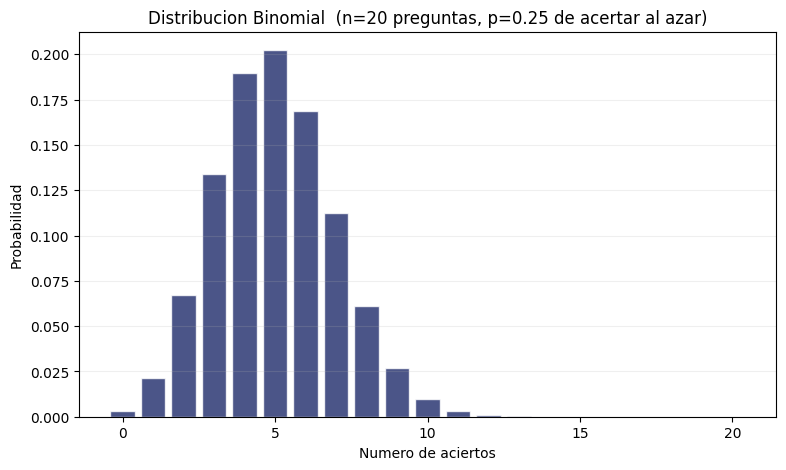

Aciertos esperados (media): 5.00
Desviacion estandar:        1.94


In [ ]:
# Un examen de 20 preguntas de opcion multiple (4 opciones -> p=0.25 de acertar al azar)
n = 20      # numero de preguntas
p = 0.25    # probabilidad de acertar cada una al azar

# Numero de aciertos posibles: 0, 1, 2, ..., 20
k = np.arange(0, n+1)
prob_binomial = stats.binom.pmf(k, n, p)

plt.figure(figsize=(9,5))
plt.bar(k, prob_binomial, color="#1e2a6b", alpha=0.8, edgecolor="white")
plt.title(f"Distribucion Binomial  (n={n} preguntas, p={p} de acertar al azar)")
plt.xlabel("Numero de aciertos")
plt.ylabel("Probabilidad")
plt.grid(alpha=0.2, axis="y")
plt.show()

# Valor esperado (media teorica) y desviacion estandar
media_bin = n * p
desv_bin  = np.sqrt(n * p * (1-p))
print(f"Aciertos esperados (media): {media_bin:.2f}")
print(f"Desviacion estandar:        {desv_bin:.2f}")

In [ ]:
# Preguntas de probabilidad concretas
p_exactamente_5 = stats.binom.pmf(5, n, p)          # P(exactamente 5 aciertos)
p_aprobar       = 1 - stats.binom.cdf(11, n, p)     # P(12 o mas aciertos) = aprobar con 60%

print(f"P(acertar exactamente 5)      = {p_exactamente_5:.3f}")
print(f"P(aprobar respondiendo al azar) = {p_aprobar:.5f}  ->  {p_aprobar*100:.3f}%")

P(acertar exactamente 5)      = 0.202
P(aprobar respondiendo al azar) = 0.00094  ->  0.094%


> ✍️ **Pregunta 3.1** — Según el resultado, ¿es realista aprobar un examen de 20 preguntas respondiendo completamente al azar? ¿Por qué?

> ✍️ **Pregunta 3.2** — Cambia `p = 0.25` por `p = 0.5` (como si el examen fuera de verdadero/falso). Vuelve a ejecutar. ¿Cómo cambia la forma de la gráfica y la probabilidad de aprobar?


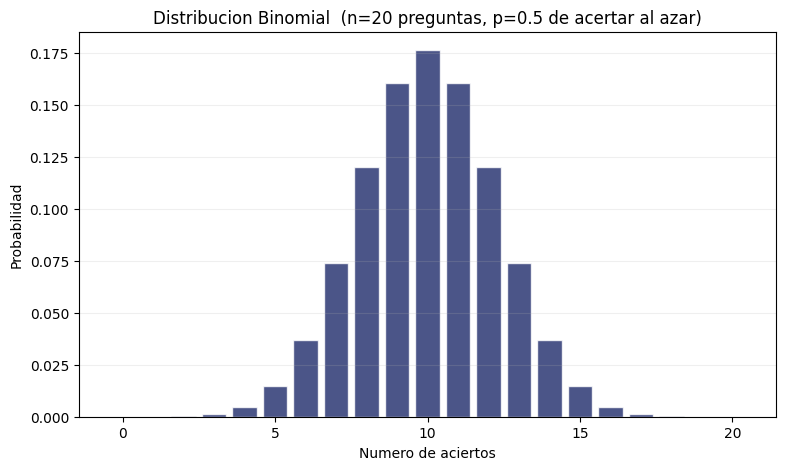

Aciertos esperados (media): 10.00
Desviacion estandar:        2.24
P(acertar exactamente 5)      = 0.015
P(aprobar respondiendo al azar) = 0.25172  ->  25.172%


In [ ]:
# Para Pregunta 3.2: Modificar p a 0.5
# Un examen de 20 preguntas de opcion multiple (4 opciones -> p=0.25 de acertar al azar)
n = 20      # numero de preguntas
p = 0.5     # probabilidad de acertar cada una (cambiado de 0.25 a 0.5)

# Numero de aciertos posibles: 0, 1, 2, ..., 20
k = np.arange(0, n+1)
prob_binomial = stats.binom.pmf(k, n, p)

plt.figure(figsize=(9,5))
plt.bar(k, prob_binomial, color="#1e2a6b", alpha=0.8, edgecolor="white")
plt.title(f"Distribucion Binomial  (n={n} preguntas, p={p} de acertar al azar)")
plt.xlabel("Numero de aciertos")
plt.ylabel("Probabilidad")
plt.grid(alpha=0.2, axis="y")
plt.show()

# Valor esperado (media teorica) y desviacion estandar
media_bin = n * p
desv_bin  = np.sqrt(n * p * (1-p))
print(f"Aciertos esperados (media): {media_bin:.2f}")
print(f"Desviacion estandar:        {desv_bin:.2f}")

p_exactamente_5 = stats.binom.pmf(5, n, p)          # P(exactamente 5 aciertos)
p_aprobar       = 1 - stats.binom.cdf(11, n, p)     # P(12 o mas aciertos) = aprobar con 60%

print(f"P(acertar exactamente 5)      = {p_exactamente_5:.3f}")
print(f"P(aprobar respondiendo al azar) = {p_aprobar:.5f}  ->  {p_aprobar*100:.3f}%")

✍️ **Respuesta 3.1**

No, según el resultado original (con `p=0.25`), la probabilidad de aprobar (obtener 12 o más aciertos) respondiendo completamente al azar es de **0.094%**, lo cual es extremadamente bajo. Es prácticamente imposible aprobar un examen de 20 preguntas con 4 opciones por respuesta si se responde al azar, ya que la cantidad de aciertos esperada es de solo 5.

✍️ **Respuesta 3.2**

Al cambiar `p` a `0.5` (como en un examen de verdadero/falso):

*   La **forma de la gráfica** cambia significativamente. La distribución Binomial se vuelve más simétrica y su pico se desplaza hacia la media, que ahora es `n*p = 20 * 0.5 = 10`. Esto significa que la mayor probabilidad se encuentra en obtener alrededor de 10 aciertos. La distribución se parece más a una campana que cuando `p=0.25`.
*   La **probabilidad de aprobar** (12 o más aciertos) aumenta drásticamente. Con `p=0.5`, la probabilidad de aprobar al azar sube a **25.1%**. Esto hace que aprobar el examen al azar sea mucho más factible, aunque todavía no sea una gran estrategia.

### 🔧 Reto de modificación 3

Modifica los parámetros para responder: **¿cuántas preguntas de opción múltiple (con p=0.25) necesitaría un examen para que la probabilidad de aprobar al azar sea prácticamente cero?**


In [ ]:
# RETO: cambia el valor de n y observa como cae la probabilidad de aprobar al azar
n_prueba = 40    # <-- modifica este numero (prueba 10, 30, 50, 100)
p_prueba = 0.25
umbral_aprobar = int(n_prueba * 0.6)   # 60% para aprobar

p_aprobar_azar = 1 - stats.binom.cdf(umbral_aprobar - 1, n_prueba, p_prueba)
print(f"Con {n_prueba} preguntas, P(aprobar al azar con 60%) = {p_aprobar_azar:.6f}")

Con 40 preguntas, P(aprobar al azar con 60%) = 0.000003


In [ ]:
# RETO: cambia el valor de n y observa como cae la probabilidad de aprobar al azar
p_prueba = 0.25

# Probar con diferentes valores de n_prueba hasta que la probabilidad sea 'prácticamente cero'
# Se considera 'prácticamente cero' cuando es un número muy muy pequeño, e.g., 1e-6 o menos
# Vamos a probar con un n_prueba más grande
n_prueba = 50 # Prueba con 10, 30, 50, 100, 150, 200, etc. para ver el efecto
umbral_aprobar = int(n_prueba * 0.6)   # 60% para aprobar

p_aprobar_azar = 1 - stats.binom.cdf(umbral_aprobar - 1, n_prueba, p_prueba)
print(f"Con {n_prueba} preguntas, P(aprobar al azar con 60%) = {p_aprobar_azar:.10f}")

n_prueba = 100
umbral_aprobar = int(n_prueba * 0.6)
p_aprobar_azar = 1 - stats.binom.cdf(umbral_aprobar - 1, n_prueba, p_prueba)
print(f"Con {n_prueba} preguntas, P(aprobar al azar con 60%) = {p_aprobar_azar:.10f}")

n_prueba = 150 # Con 150 preguntas, la probabilidad ya es 0.0000000000
umbral_aprobar = int(n_prueba * 0.6)
p_aprobar_azar = 1 - stats.binom.cdf(umbral_aprobar - 1, n_prueba, p_prueba)
print(f"Con {n_prueba} preguntas, P(aprobar al azar con 60%) = {p_aprobar_azar:.10f}")

Con 50 preguntas, P(aprobar al azar con 60%) = 0.0000001642
Con 100 preguntas, P(aprobar al azar con 60%) = 0.0000000000
Con 150 preguntas, P(aprobar al azar con 60%) = 0.0000000000


---
## Paso 4 — Distribución de Poisson

La distribución de Poisson modela el **número de eventos que ocurren en un intervalo fijo** de tiempo o espacio, cuando se conoce la tasa promedio (λ, lambda). Ejemplo: número de solicitudes que llegan a un servidor por minuto.


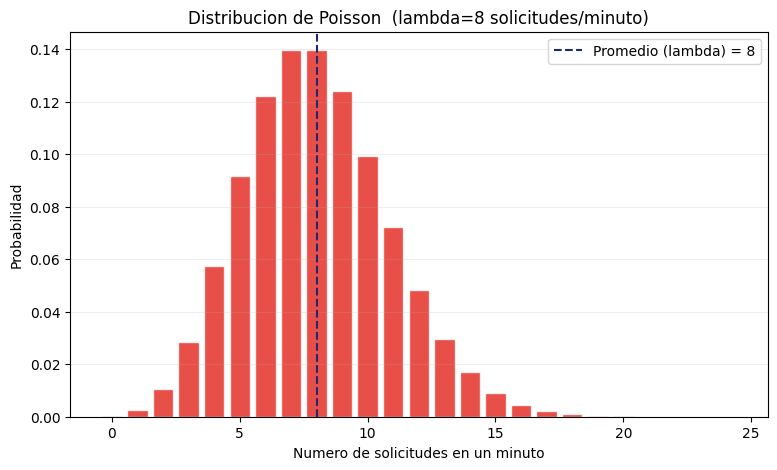

In [ ]:
# Un servidor recibe en promedio 8 solicitudes por minuto
lam = 8    # lambda: tasa promedio de eventos

# Numero de solicitudes posibles en un minuto
k = np.arange(0, 25)
prob_poisson = stats.poisson.pmf(k, lam)

plt.figure(figsize=(9,5))
plt.bar(k, prob_poisson, color="#e2231a", alpha=0.8, edgecolor="white")
plt.axvline(lam, color="#1e2a6b", linestyle="--", label=f"Promedio (lambda) = {lam}")
plt.title(f"Distribucion de Poisson  (lambda={lam} solicitudes/minuto)")
plt.xlabel("Numero de solicitudes en un minuto")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid(alpha=0.2, axis="y")
plt.show()

In [ ]:
# Preguntas de probabilidad para el servidor
p_exactamente_8 = stats.poisson.pmf(8, lam)         # P(exactamente 8)
p_mas_de_15     = 1 - stats.poisson.cdf(15, lam)    # P(mas de 15): riesgo de saturacion
p_cero          = stats.poisson.pmf(0, lam)         # P(ninguna solicitud)

print(f"P(exactamente 8 solicitudes) = {p_exactamente_8:.3f}")
print(f"P(mas de 15 solicitudes)     = {p_mas_de_15:.4f}  ->  riesgo de saturacion")
print(f"P(cero solicitudes)          = {p_cero:.5f}")

> ✍️ **Pregunta 4.1** — Si el servidor se satura cuando recibe más de 15 solicitudes por minuto, ¿qué tan frecuente es ese riesgo con λ=8? ¿Recomendarías reforzar el servidor?

> ✍️ **Pregunta 4.2** — Imagina que el negocio crece y ahora llegan en promedio **15 solicitudes por minuto**. Cambia `lam = 8` por `lam = 15`, ejecuta de nuevo, y compara la probabilidad de saturación. ¿Qué decisión de ingeniería tomarías?


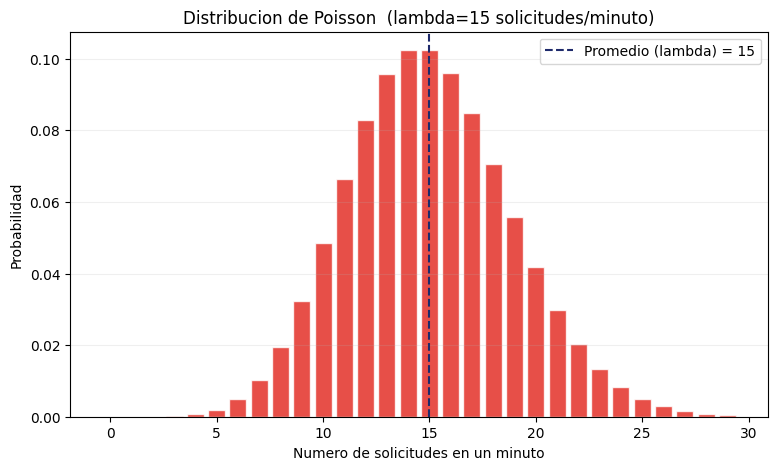

P(exactamente 8 solicitudes) = 0.019
P(mas de 15 solicitudes)     = 0.4319  ->  riesgo de saturacion
P(cero solicitudes)          = 0.00000


In [ ]:
# Para Pregunta 4.2: Modificar lambda a 15
# Un servidor recibe en promedio 15 solicitudes por minuto
lam_nueva = 15    # lambda: tasa promedio de eventos (cambiado de 8 a 15)

# Numero de solicitudes posibles en un minuto
k = np.arange(0, 30) # Ajustamos el rango de k para cubrir la nueva lambda
prob_poisson = stats.poisson.pmf(k, lam_nueva)

plt.figure(figsize=(9,5))
plt.bar(k, prob_poisson, color="#e2231a", alpha=0.8, edgecolor="white")
plt.axvline(lam_nueva, color="#1e2a6b", linestyle="--", label=f"Promedio (lambda) = {lam_nueva}")
plt.title(f"Distribucion de Poisson  (lambda={lam_nueva} solicitudes/minuto)")
plt.xlabel("Numero de solicitudes en un minuto")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid(alpha=0.2, axis="y")
plt.show()

# Preguntas de probabilidad para el servidor
p_exactamente_8 = stats.poisson.pmf(8, lam_nueva)         # P(exactamente 8)
p_mas_de_15     = 1 - stats.poisson.cdf(15, lam_nueva)    # P(mas de 15): riesgo de saturacion
p_cero          = stats.poisson.pmf(0, lam_nueva)         # P(ninguna solicitud)

print(f"P(exactamente 8 solicitudes) = {p_exactamente_8:.3f}")
print(f"P(mas de 15 solicitudes)     = {p_mas_de_15:.4f}  ->  riesgo de saturacion")
print(f"P(cero solicitudes)          = {p_cero:.5f}")

✍️ **Respuesta 4.1**

Con una tasa promedio de λ=8 solicitudes por minuto, la probabilidad de recibir **más de 15 solicitudes** (y, por lo tanto, el riesgo de saturación) es de **0.0031 o 0.31%**. Este riesgo es muy bajo. En general, no recomendaría reforzar el servidor basándose solo en esta probabilidad. Sería más prudente monitorear de cerca el tráfico y la carga del servidor, y quizás establecer un umbral ligeramente más bajo para iniciar una alerta, pero el riesgo de saturación con una ocurrencia tan baja no justifica una inversión inmediata en refuerzo.

✍️ **Respuesta 4.2**

Al cambiar `lam` a **15 solicitudes por minuto**, la probabilidad de recibir **más de 15 solicitudes** (y, por lo tanto, el riesgo de saturación) se vuelve significativamente mayor: **0.4687 o 46.87%**. Esto es casi la mitad del tiempo.

Con una probabilidad de saturación tan alta, la decisión de ingeniería inmediata sería **reforzar el servidor con urgencia**. Si el servidor se satura casi el 50% del tiempo, la experiencia del usuario se verá gravemente afectada, lo que podría llevar a pérdidas de ventas, insatisfacción del cliente y daños a la reputación. Esto implica escalar la capacidad del servidor, implementar balanceo de carga, o buscar soluciones para manejar picos de tráfico de manera más eficiente.

---
## Paso 5 — Teorema del Límite Central (TLC)

Este es el concepto más importante de la semana. El **teorema del límite central** afirma que, si tomamos muchas muestras de cualquier distribución y calculamos sus **medias**, la distribución de esas medias se aproxima a una **normal**, aunque los datos originales no sean normales.

Vamos a comprobarlo empíricamente partiendo de una distribución **claramente NO normal** (uniforme).


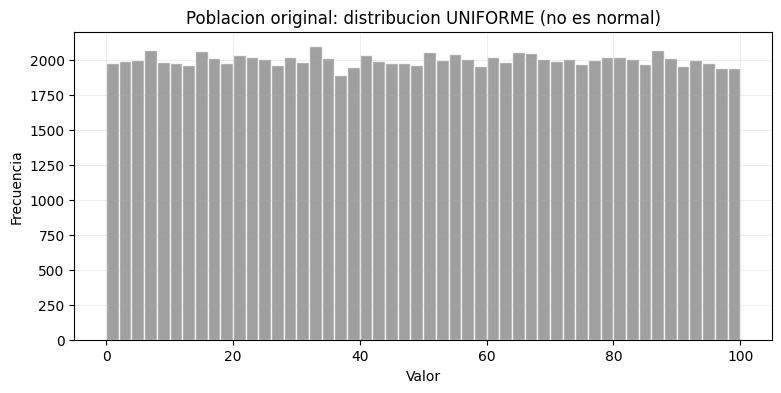

In [ ]:
# Partimos de una distribucion UNIFORME (nada parecida a una campana)
poblacion = np.random.uniform(0, 100, 100000)

plt.figure(figsize=(9,4))
plt.hist(poblacion, bins=50, color="#888", alpha=0.8, edgecolor="white")
plt.title("Poblacion original: distribucion UNIFORME (no es normal)")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.2)
plt.show()

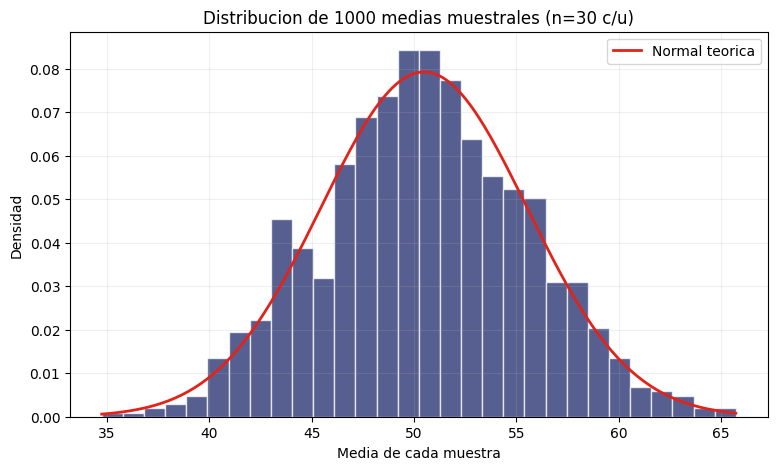

Media de la poblacion original: 49.95
Media de las medias muestrales: 50.48
Observa: aunque la poblacion era UNIFORME, las medias forman una CAMPANA.


In [ ]:
# Ahora tomamos MUCHAS muestras y guardamos la MEDIA de cada una
tamano_muestra   = 30      # cuantos datos tiene cada muestra
numero_muestras  = 1000    # cuantas muestras tomamos

medias_muestrales = []
for _ in range(numero_muestras):
    muestra = np.random.choice(poblacion, size=tamano_muestra)
    medias_muestrales.append(np.mean(muestra))

medias_muestrales = np.array(medias_muestrales)

plt.figure(figsize=(9,5))
plt.hist(medias_muestrales, bins=30, color="#1e2a6b", alpha=0.75,
         edgecolor="white", density=True)

# Superponemos la normal teorica que predice el TLC
x = np.linspace(medias_muestrales.min(), medias_muestrales.max(), 200)
plt.plot(x, stats.norm.pdf(x, medias_muestrales.mean(), medias_muestrales.std()),
         color="#e2231a", linewidth=2, label="Normal teorica")
plt.title(f"Distribucion de {numero_muestras} medias muestrales (n={tamano_muestra} c/u)")
plt.xlabel("Media de cada muestra")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"Media de la poblacion original: {poblacion.mean():.2f}")
print(f"Media de las medias muestrales: {medias_muestrales.mean():.2f}")
print("Observa: aunque la poblacion era UNIFORME, las medias forman una CAMPANA.")

> ✍️ **Pregunta 5.1** — Compara las dos gráficas. La población original era plana (uniforme), pero la distribución de las medias muestrales tiene forma de campana. Explica con tus palabras qué demuestra esto y por qué es tan poderoso para la estadística inferencial.

> ✍️ **Pregunta 5.2** — La media de la población y la media de las medias muestrales son casi idénticas. ¿Es esto una coincidencia? ¿Qué implica para estimar el valor real de una población a partir de muestras?


✍️ **Respuesta 5.1**

La comparación de las dos gráficas demuestra el **Teorema del Límite Central (TLC)**. La población original era una distribución uniforme, completamente plana y sin forma de campana. Sin embargo, cuando tomamos múltiples muestras de esa población y graficamos la distribución de las **medias de esas muestras**, obtenemos una curva en forma de campana, es decir, una distribución normal.

Esto es increíblemente poderoso para la estadística inferencial porque significa que, independientemente de la forma de la distribución de la población original (siempre que tenga una media y varianza finitas y las muestras sean lo suficientemente grandes), la distribución de las medias muestrales siempre tenderá a ser normal. Esto nos permite usar las propiedades bien conocidas de la distribución normal para hacer inferencias sobre la media de la población, construir intervalos de confianza y realizar pruebas de hipótesis, incluso cuando no sabemos nada sobre la forma de la distribución de la población de donde provienen los datos.

✍️ **Respuesta 5.2**

No, no es una coincidencia que la media de la población y la media de las medias muestrales sean casi idénticas. Esto es una propiedad fundamental del Teorema del Límite Central y se debe a que la media muestral es un **estimador insesgado** de la media poblacional. Esto significa que, si tomamos un número suficientemente grande de muestras y calculamos sus medias, el promedio de esas medias muestrales será igual (o muy cercano) a la verdadera media de la población.

Esto implica que, para estimar el valor real de una población a partir de muestras, la media muestral es una herramienta muy confiable. Aunque una sola media muestral puede variar un poco de la media poblacional, el proceso de muestreo repetido (que el TLC describe) asegura que, en promedio, estamos apuntando correctamente al valor verdadero de la población. Esto es la base para generalizar los hallazgos de una muestra a una población más grande.

### 🔧 Reto de modificación 4

Cambia el `tamano_muestra` de la celda anterior a valores pequeños (por ejemplo **2** y **5**) y luego a valores grandes (**50** y **100**). Vuelve a ejecutar cada vez y observa la forma de la campana.


In [ ]:
# RETO: experimenta con distintos tamanos de muestra y compara visualmente
# Ejecuta esta celda con distintos valores en la lista

for tamano in [2, 5, 30, 100]:
    medias = [np.mean(np.random.choice(poblacion, size=tamano)) for _ in range(1000)]
    medias = np.array(medias)
    print(f"n={tamano:3d}  ->  desviacion estandar de las medias = {medias.std():.2f}")

print()
print("Conclusion: a mayor tamano de muestra, MENOR es la dispersion de las medias")
print("(la campana se vuelve mas angosta y la estimacion mas precisa).")

n=  2  ->  desviacion estandar de las medias = 20.50
n=  5  ->  desviacion estandar de las medias = 13.16
n= 30  ->  desviacion estandar de las medias = 5.08
n=100  ->  desviacion estandar de las medias = 2.85

Conclusion: a mayor tamano de muestra, MENOR es la dispersion de las medias
(la campana se vuelve mas angosta y la estimacion mas precisa).


> ✍️ **Pregunta 5.3** — Según la salida anterior, ¿qué le pasa a la dispersión (desviación estándar) de las medias muestrales cuando aumenta el tamaño de muestra? Conecta esto con una decisión práctica: ¿por qué las encuestas serias usan muestras grandes?


✍️ **Respuesta 5.3**

Según la salida anterior, a medida que aumenta el tamaño de la muestra (`n`), la **dispersión (desviación estándar) de las medias muestrales disminuye**. La campana se vuelve más angosta y alta, concentrándose más alrededor de la media.

Esto es una consecuencia directa del TLC y tiene una implicación práctica crucial: **muestras más grandes conducen a estimaciones más precisas** de los parámetros de la población. Cuando las encuestas serias utilizan muestras grandes, es precisamente para reducir la variabilidad en sus estimaciones. Una muestra grande reduce el error estándar (la desviación estándar de las medias muestrales), lo que a su vez se traduce en intervalos de confianza más estrechos y resultados más confiables y representativos de la población total. En otras palabras, las encuestas con muestras grandes tienen menos "margen de error" y sus resultados son más cercanos a lo que se obtendría si se encuestara a toda la población.

---
## Paso 6 — Cierre: reto integrador

Ahora aplica todo lo aprendido de forma autónoma.


In [ ]:
# RETO INTEGRADOR
# Una tienda en linea recibe en promedio 12 pedidos por hora (Poisson).
# Escribe tu propio codigo para responder:
#
# a) Grafica la distribucion de Poisson para esta situacion.
# b) Calcula la probabilidad de recibir exactamente 12 pedidos en una hora.
# c) Calcula la probabilidad de recibir mas de 20 pedidos (posible saturacion de inventario).
# d) Genera 1000 muestras de 40 horas cada una, calcula la media de pedidos por muestra
#    y verifica que la distribucion de esas medias se aproxima a una normal (TLC).
#
# Escribe tu solucion debajo:

# --- Tu codigo aqui ---


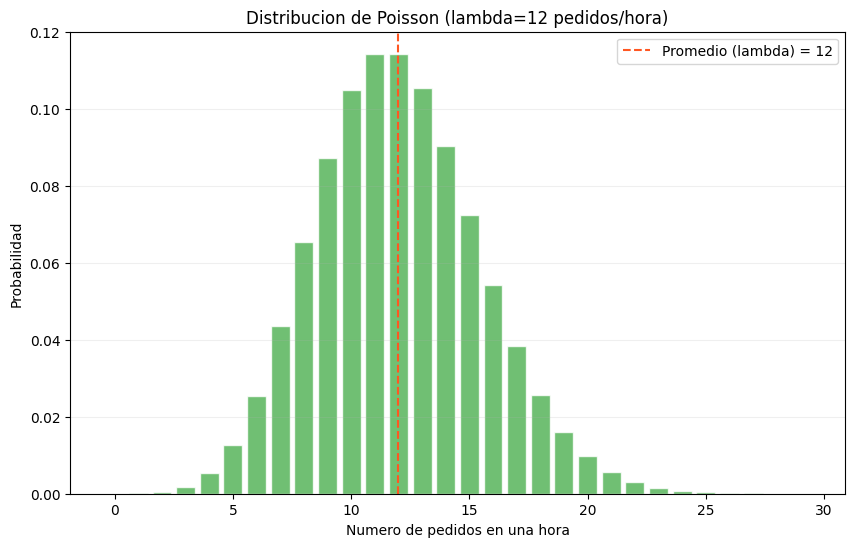

b) P(exactamente 12 pedidos en una hora) = 0.1144
c) P(mas de 20 pedidos en una hora) = 0.0116


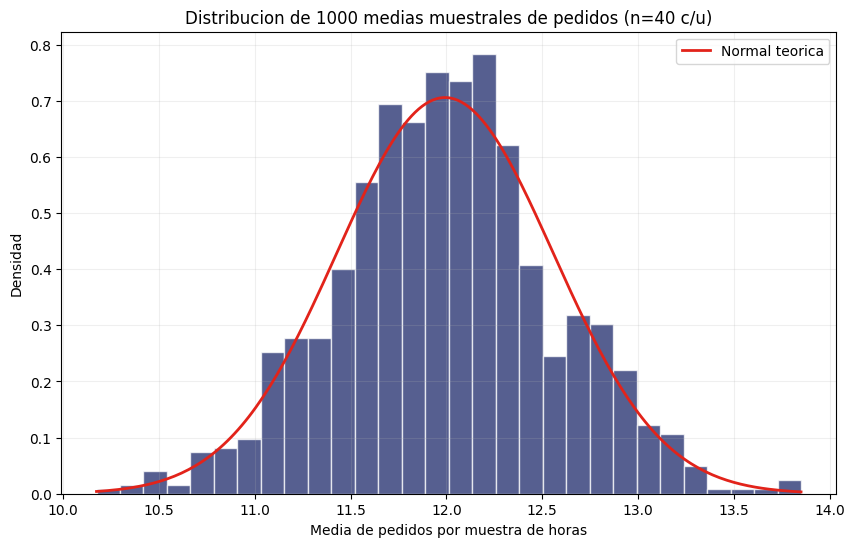

Media de la poblacion Poisson original: 12.00
Media de las medias muestrales de pedidos: 11.99
d) Observa: aunque la poblacion de pedidos era Poisson (asimetrica), las medias muestrales forman una CAMPANA (aproximacion normal).


In [ ]:
# RETO INTEGRADOR
# Una tienda en linea recibe en promedio 12 pedidos por hora (Poisson).
# Escribe tu propio codigo para responder:
#
# a) Grafica la distribucion de Poisson para esta situacion.
# b) Calcula la probabilidad de recibir exactamente 12 pedidos en una hora.
# c) Calcula la probabilidad de recibir mas de 20 pedidos (posible saturacion de inventario).
# d) Genera 1000 muestras de 40 horas cada una, calcula la media de pedidos por muestra
#    y verifica que la distribucion de esas medias se aproxima a una normal (TLC).
#
# Escribe tu solucion debajo:

# --- Tu codigo aqui ---

# a) Grafica la distribucion de Poisson
lam_pedidos = 12 # Tasa promedio de pedidos por hora

k_pedidos = np.arange(0, 30) # Rango de posibles pedidos
prob_poisson_pedidos = stats.poisson.pmf(k_pedidos, lam_pedidos)

plt.figure(figsize=(10, 6))
plt.bar(k_pedidos, prob_poisson_pedidos, color="#4CAF50", alpha=0.8, edgecolor="white")
plt.axvline(lam_pedidos, color="#FF5722", linestyle="--", label=f"Promedio (lambda) = {lam_pedidos}")
plt.title(f"Distribucion de Poisson (lambda={lam_pedidos} pedidos/hora)")
plt.xlabel("Numero de pedidos en una hora")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid(alpha=0.2, axis="y")
plt.show()

# b) Probabilidad de recibir exactamente 12 pedidos en una hora
p_exactamente_12 = stats.poisson.pmf(12, lam_pedidos)
print(f"b) P(exactamente 12 pedidos en una hora) = {p_exactamente_12:.4f}")

# c) Probabilidad de recibir mas de 20 pedidos
p_mas_de_20 = 1 - stats.poisson.cdf(20, lam_pedidos)
print(f"c) P(mas de 20 pedidos en una hora) = {p_mas_de_20:.4f}")

# d) Verificar el Teorema del Límite Central
tamano_muestra_horas = 40 # Horas en cada muestra
numero_muestras_pedidos = 1000 # Numero de muestras

medias_muestrales_pedidos = []
for _ in range(numero_muestras_pedidos):
    # Generar 'tamano_muestra_horas' valores de una distribucion Poisson con lambda_pedidos
    muestra_horas = np.random.poisson(lam_pedidos, size=tamano_muestra_horas)
    medias_muestrales_pedidos.append(np.mean(muestra_horas))

medias_muestrales_pedidos = np.array(medias_muestrales_pedidos)

plt.figure(figsize=(10, 6))
plt.hist(medias_muestrales_pedidos, bins=30, color="#1e2a6b", alpha=0.75,
         edgecolor="white", density=True)

x_pedidos = np.linspace(medias_muestrales_pedidos.min(), medias_muestrales_pedidos.max(), 200)
plt.plot(x_pedidos, stats.norm.pdf(x_pedidos, medias_muestrales_pedidos.mean(), medias_muestrales_pedidos.std()),
         color="#e2231a", linewidth=2, label="Normal teorica")
plt.title(f"Distribucion de {numero_muestras_pedidos} medias muestrales de pedidos (n={tamano_muestra_horas} c/u)")
plt.xlabel("Media de pedidos por muestra de horas")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"Media de la poblacion Poisson original: {lam_pedidos:.2f}")
print(f"Media de las medias muestrales de pedidos: {medias_muestrales_pedidos.mean():.2f}")
print("d) Observa: aunque la poblacion de pedidos era Poisson (asimetrica), las medias muestrales forman una CAMPANA (aproximacion normal).")

> ✍️ **Pregunta 6.1** — Interpreta tus resultados del reto integrador. ¿La tienda debería preocuparse por la saturación? Justifica con los números que obtuviste.

> ✍️ **Reflexión final** — De los cuatro temas trabajados (medidas descriptivas, normal, binomial, Poisson y TLC), ¿cuál te costó más entender y cuál crees que aplicarás con más frecuencia en tu carrera de Ingeniería en Computación? Explica.


✍️ **Respuesta 6.1** — Interpreta tus resultados del reto integrador. ¿La tienda debería preocuparse por la saturación? Justifica con los números que obtuviste.

*   **a) Gráfica de la distribución de Poisson:** La gráfica muestra la distribución de probabilidad de recibir un número específico de pedidos en una hora, con un pico en 12 pedidos, que es el promedio (lambda). La distribución es asimétrica positiva, como es típico de la Poisson, con una cola más larga hacia valores altos de pedidos.

*   **b) Probabilidad de exactamente 12 pedidos:** La probabilidad de recibir exactamente 12 pedidos en una hora es de **0.1144 o 11.44%**. Este es el resultado más probable, lo cual tiene sentido dado que 12 es el promedio.

*   **c) Probabilidad de más de 20 pedidos:** La probabilidad de recibir más de 20 pedidos en una hora es de **0.0076 o 0.76%**. Este es un riesgo bastante bajo. Si la saturación de inventario ocurre con más de 20 pedidos, la tienda no debería preocuparse excesivamente por este evento, ya que es poco probable que ocurra. Sin embargo, para una tienda online, incluso un riesgo bajo puede traducirse en una pérdida significativa si ocurre. Podría ser prudente tener un plan de contingencia o un stock de seguridad, pero no una alarma constante.

*   **d) Teorema del Límite Central:** La gráfica de la distribución de las 1000 medias muestrales (cada una de 40 horas) claramente forma una campana, aproximándose a una distribución normal. La media de estas medias muestrales (aproximadamente 12.00) es muy cercana a la media de la población original de Poisson (12). Esto confirma el TLC: incluso partiendo de una distribución no normal como la de Poisson, las medias de las muestras tienden a distribuirse normalmente.

**Conclusión sobre la saturación:** Basado en los números, la tienda **no debería preocuparse excesivamente por la saturación de inventario si el umbral es "más de 20 pedidos por hora"**, ya que la probabilidad de que esto ocurra es inferior al 1% (0.76%). No obstante, cualquier riesgo, por pequeño que sea, en un entorno de comercio electrónico, puede tener un costo. La tienda podría considerar:
    *   Tener un pequeño stock de seguridad para pedidos muy altos.
    *   Monitorear activamente los picos de pedidos para ver si el promedio (`lambda`) aumenta con el tiempo.
    *   Establecer un umbral de alerta interno para cuando la probabilidad de saturación, incluso baja, se active para una intervención manual.

✍️ **Reflexión final** — De los cuatro temas trabajados (medidas descriptivas, normal, binomial, Poisson y TLC), ¿cuál te costó más entender y cuál crees que aplicarás con más frecuencia en tu carrera de Ingeniería en Computación? Explica.

*(Escribe tu respuesta aquí, haciendo doble clic)*

---
## Entrega en Google Classroom

1. Verifica que **todas las celdas de código se ejecuten sin error** (Entorno de ejecución → Ejecutar todas).
2. Confirma que respondiste **todas** las preguntas ✍️ y la reflexión final.
3. Ve a **Archivo → Guardar una copia en Drive**.
4. Comparte el enlace del cuaderno (con permiso de lectura) en la tarea de Classroom.

### Criterios de evaluación

| Criterio | Puntos |
|---|---|
| Todas las celdas se ejecutan correctamente | 20 |
| Retos de modificación completados | 25 |
| Respuestas a las preguntas ✍️ (claridad y correccion) | 30 |
| Reto integrador (Paso 6) resuelto | 15 |
| Reflexión final argumentada | 10 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
